### Imports 

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from bs4 import BeautifulSoup
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import Dataset
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    pipeline
)

print("PyTorch     :", torch.__version__)
print("CUDA available:", torch.cuda.is_available())  # False on CPU is fine

/home/rishabh/Desktop/projects/sentiment_analysis_IMDB/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch     : 2.13.0+cu129
CUDA available: True


### DATA Loading 

In [2]:
data = pd.read_csv("../dataset/IMDB Dataset.csv")

# Encode labels
data['label'] = data['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)

print("Dataset shape  :", data.shape)
print("Label balance  :\n", data['label'].value_counts())
print("\nSample review  :\n", data['review'].iloc[0][:300])

Dataset shape  : (50000, 3)
Label balance  :
 label
1    25000
0    25000
Name: count, dtype: int64

Sample review  :
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru


### Preprocessing

In [3]:


def clean_text(text):
    # Remove HTML tags (IMDB reviews contain <br />, <b> etc.)
    text = BeautifulSoup(text, "html.parser").get_text()
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data['review'] = data['review'].apply(clean_text)

# Verify
print("After cleaning:")
print(data['review'].iloc[0][:300])

After cleaning:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this 


## Train Test Split 

In [4]:
## train (70%) / validation (15%) / test (15%)
## validation is used for early stopping / best-checkpoint selection during
## training; test is only touched once, at the very end, for the final report
X_train, X_temp, y_train, y_temp = train_test_split(
    data['review'].tolist(),
    data['label'].tolist(),
    test_size  = 0.3,
    random_state = 42,
    stratify   = data['label'].tolist()
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size  = 0.5,
    random_state = 42,
    stratify   = y_temp
)

print("Train size :", len(X_train))
print("Val size   :", len(X_val))
print("Test size  :", len(X_test))
print("Train label balance:", pd.Series(y_train).value_counts().tolist())
print("Val label balance  :", pd.Series(y_val).value_counts().tolist())
print("Test label balance :", pd.Series(y_test).value_counts().tolist())

Train size : 35000
Val size   : 7500
Test size  : 7500
Train label balance: [17500, 17500]
Val label balance  : [3750, 3750]
Test label balance : [3750, 3750]


### Tokenizer & Dataset 

In [5]:
# ─────────────────────────────────────────────────────────────
# DistilBERT WordPiece tokenizer:
# - Splits unknown words into subwords
#   e.g. "cinematography" → ["cinema", "##tog", "##raphy"]
# - Adds [CLS] token at start (used for classification)
# - Adds [SEP] token at end (sentence boundary)
# - Pads all sequences to same length
# - max_length=256 covers 95%+ of IMDB reviews
# ─────────────────────────────────────────────────────────────

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class IMDBDataset(Dataset):
    def __init__(self, texts, labels):
        print(f"Tokenizing {len(texts)} reviews...")
        self.encodings = tokenizer(
            texts,
            truncation = True,   # cut reviews longer than max_length
            padding    = True,   # pad shorter reviews with [PAD] token
            max_length = 128
        )
        self.labels = labels
        print("Done!")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Returns one sample — input_ids, attention_mask, label
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_dataset = IMDBDataset(X_train, y_train)
val_dataset   = IMDBDataset(X_val,   y_val)
test_dataset  = IMDBDataset(X_test,  y_test)

Tokenizing 35000 reviews...


Done!
Tokenizing 7500 reviews...


Done!
Tokenizing 7500 reviews...


Done!


### Loading pretrained Models

In [6]:
# ─────────────────────────────────────────────────────────────
# Loading pretrained DistilBERT and adding a classification head
#
# distilbert-base-uncased:
# - Trained on BookCorpus + Wikipedia (3.3B words)
# - 6 transformer layers, 12 attention heads
# - Already understands grammar, negation, context
# - We just add a 2-class output layer on top
# ─────────────────────────────────────────────────────────────

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels = 2   # 0 = Negative, 1 = Positive
)

# Check model size
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable:,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 13799.32it/s]


[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters    : 66,955,010
Trainable parameters: 66,955,010


### Train

In [7]:
# ─────────────────────────────────────────────────────────────
# Fine-tuning strategy:
# - Only 3 epochs — more causes overfitting on pretrained model
# - lr = 2e-5 — very small to preserve pretrained knowledge
# - warmup_steps — gradually increase lr at start of training
# - Trainer handles: lr scheduling, gradient clipping,
#   checkpointing, evaluation automatically
# - eval_dataset is the held-out VALIDATION set, not the test set —
#   test_dataset stays untouched until final evaluation below
# ─────────────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score
import numpy as np
training_args = TrainingArguments(
    output_dir                  = './distilbert_imdb',
    num_train_epochs            = 3,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    learning_rate               = 2e-5,
    warmup_steps                = 200,
    weight_decay                = 0.01,
    eval_strategy                = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    logging_steps               = 200,
    logging_dir                 = './logs',
)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, predictions)}

trainer = Trainer(
    model         = model,
    args          = training_args,
    train_dataset = train_dataset,
    eval_dataset  = val_dataset,
    compute_metrics = compute_metrics,
)

trainer.train()

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.302602,0.286536,0.875467
2,0.222657,0.294589,0.882667
3,0.143561,0.333894,0.883600


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.20it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.19it/s]

...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.66it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.87it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.86it/s]

TrainOutput(global_step=3282, training_loss=0.24407756306789474, metrics={'train_runtime': 342.7389, 'train_samples_per_second': 306.356, 'train_steps_per_second': 9.576, 'total_flos': 3477269214720000.0, 'train_loss': 0.24407756306789474, 'epoch': 3.0})

### Evaluate 

── Classification Report ──
              precision    recall  f1-score   support

    Negative       0.91      0.84      0.87      3750
    Positive       0.85      0.91      0.88      3750

    accuracy                           0.88      7500
   macro avg       0.88      0.88      0.88      7500
weighted avg       0.88      0.88      0.88      7500



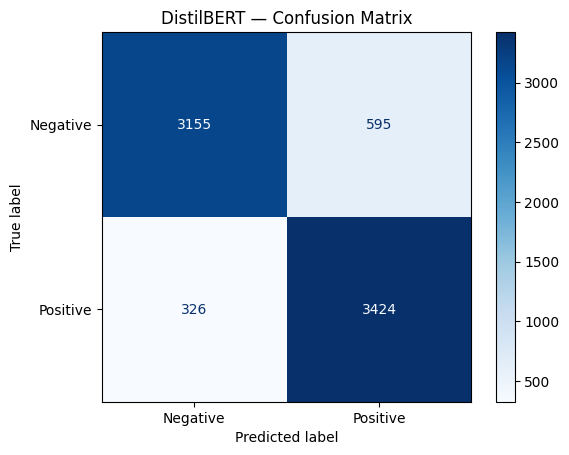

In [8]:
# Predict on test set
predictions = trainer.predict(test_dataset)
y_pred      = predictions.predictions.argmax(axis=1)

# Classification report
print("── Classification Report ──")
print(classification_report(
    y_test, y_pred,
    target_names=['Negative', 'Positive']
))

# Confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Negative', 'Positive']
)
disp.plot(cmap='Blues')
plt.title('DistilBERT — Confusion Matrix')
plt.show()

### Plot Training Curve

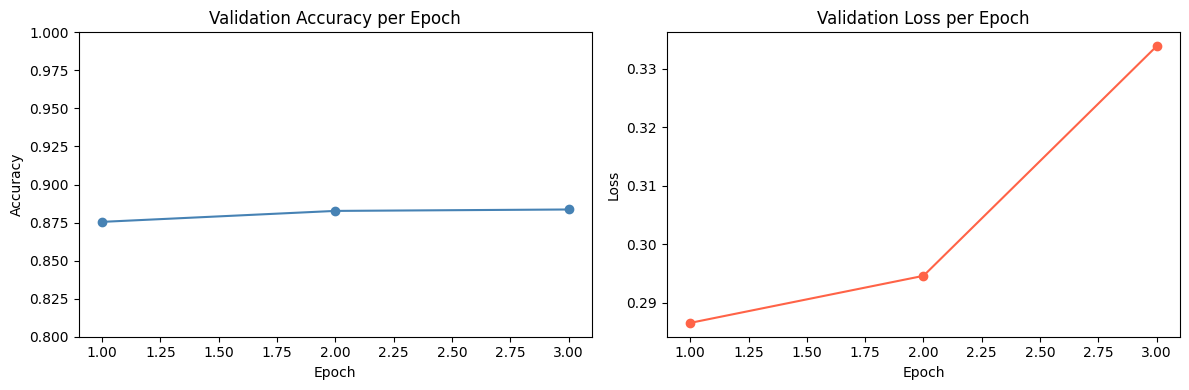

In [9]:
# Extract logs
logs      = [x for x in trainer.state.log_history if 'eval_loss' in x]
train_log = [x for x in trainer.state.log_history if 'loss' in x and 'eval_loss' not in x]

eval_loss = [x['eval_loss']     for x in logs]
eval_acc  = [x['eval_accuracy'] for x in logs]
epochs    = [x['epoch']         for x in logs]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, eval_acc,  marker='o', color='steelblue')
axes[0].set_title('Validation Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0.8, 1.0])

axes[1].plot(epochs, eval_loss, marker='o', color='tomato')
axes[1].set_title('Validation Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')

plt.tight_layout()
plt.show()

### Saving the model

In [10]:
model.save_pretrained("./distilbert_imdb_finetuned")
tokenizer.save_pretrained("./distilbert_imdb_finetuned")
print("✅ Model saved to ./distilbert_imdb_finetuned")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.22it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.22it/s]

✅ Model saved to ./distilbert_imdb_finetuned


### General comments 

In [11]:
# ─────────────────────────────────────────────────────────────
# Load saved model and test on completely general
# movie comments — nothing from training or debugging
# ─────────────────────────────────────────────────────────────

classifier = pipeline(
    "text-classification",
    model     = "./distilbert_imdb_finetuned",
    tokenizer = "./distilbert_imdb_finetuned",
    device    = 0 if torch.cuda.is_available() else -1
)

# Read the label mapping from the model config instead of assuming
# LABEL_1 == positive — id2label reflects num_labels=2 with 1=Positive
# set at training time (see "Loading pretrained Models" above), but
# checking it here means this code stays correct if that ever changes.
positive_label = classifier.model.config.id2label[1]

general_comments = [
    # Positive
    "An absolute cinematic triumph from start to finish",
    "I laughed, I cried — this film has everything",
    "The director has truly outdone himself this time",
    "Every performance in this film deserves an award",
    "Left the theatre feeling genuinely moved",

    # Negative
    "A painfully predictable and boring experience",
    "I want my money back after watching this",
    "The dialogue felt unnatural and forced throughout",
    "Poorly directed with no coherent story",
    "One of the most disappointing films of the decade",

    # Negation heavy
    "Not the kind of film I would ever recommend",
    "The movie never manages to find its footing",
    "I couldn't connect with any of the characters",
    "There was nothing remotely interesting about the plot",
    "The ending didn't make any sense whatsoever",

    # Nuanced / mixed
    "Beautiful scenery but a painfully dull story",
    "Strong opening that falls apart in the second half",
    "The lead actor shines despite a weak script",
    "Visually stunning but emotionally hollow",
    "An interesting concept that was poorly executed",
]

# Run predictions
print(f"\n{'Text':<55} {'Sentiment':<12} {'Confidence'}")
print("─" * 85)

for comment in general_comments:
    result     = classifier(clean_text(comment))[0]
    label      = "✅ Positive" if result['label'] == positive_label else "❌ Negative"
    confidence = f"{result['score']:.2%}"
    print(f"{comment:<55} {label:<12} {confidence}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 12377.49it/s]


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



Text                                                    Sentiment    Confidence
─────────────────────────────────────────────────────────────────────────────────────
An absolute cinematic triumph from start to finish      ✅ Positive   97.58%
I laughed, I cried — this film has everything           ✅ Positive   97.14%
The director has truly outdone himself this time        ✅ Positive   74.00%
Every performance in this film deserves an award        ✅ Positive   89.09%
Left the theatre feeling genuinely moved                ✅ Positive   92.40%
A painfully predictable and boring experience           ❌ Negative   99.08%
I want my money back after watching this                ❌ Negative   60.73%
The dialogue felt unnatural and forced throughout       ❌ Negative   97.30%
Poorly directed with no coherent story                  ❌ Negative   98.92%
One of the most disappointing films of the decade       ❌ Negative   92.38%
Not the kind of film I would ever recommend             ❌ Negative   93.7